# Customer Segmentation (K-Means)
### Problem Statement (Markdown)
#### The objective of this project is to segment customers into different groups based on their spending behavior and income using unsupervised learning techniques.
#### Customer segmentation helps businesses understand different customer types and design targeted marketing strategies. In this project, K-Means Clustering will be used to group customers, and PCA will be used to visualize the clusters.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Load Dataset

In [2]:
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Dataset Overview

In [3]:
data.shape

(200, 5)

In [4]:
data.shape

(200, 5)

In [5]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### EDA (Exploratory Data Analysis)

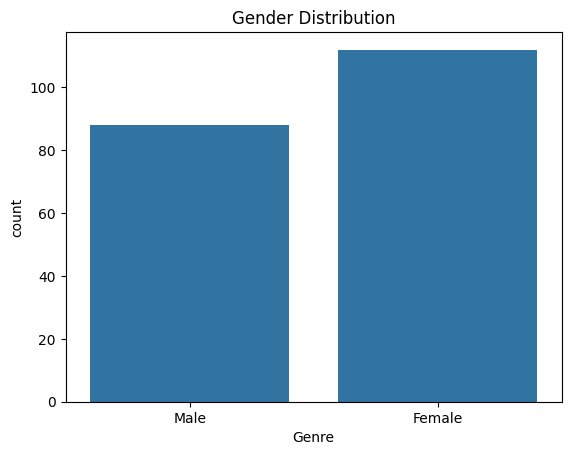

In [7]:
sns.countplot(x='Genre', data=data)
plt.title("Gender Distribution")
plt.show()

#### Age Distribution


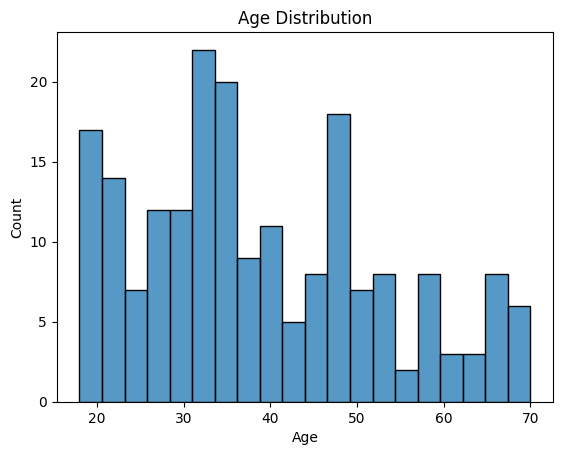

In [8]:
sns.histplot(data['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

#### Income vs Spending 

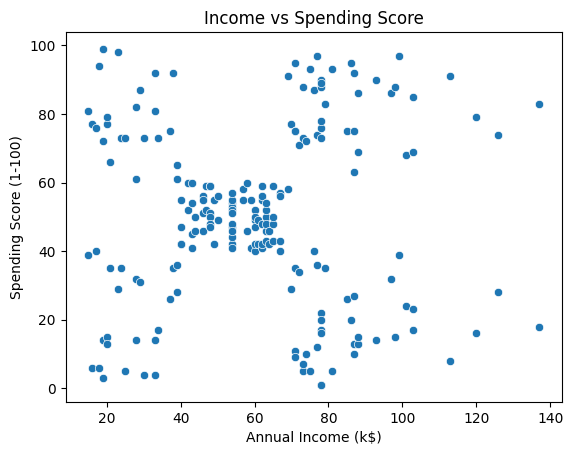

In [9]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=data
)

plt.title("Income vs Spending Score")
plt.show()

### Selecting Features

In [10]:
x = data[['Annual Income (k$)', 'Spending Score (1-100)']]

### Feature Scaling

In [13]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

### Elbow Method (Find Best Clusters)

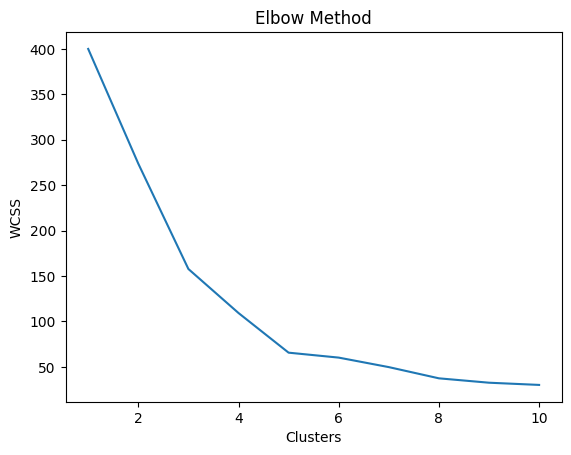

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

### Applying K-Means

In [16]:
kmeans = KMeans(n_clusters=5, random_state=42)

y_kmeans = kmeans.fit_predict(x_scaled)

data['Cluster'] = y_kmeans
print(data['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


### Visualize Clusters

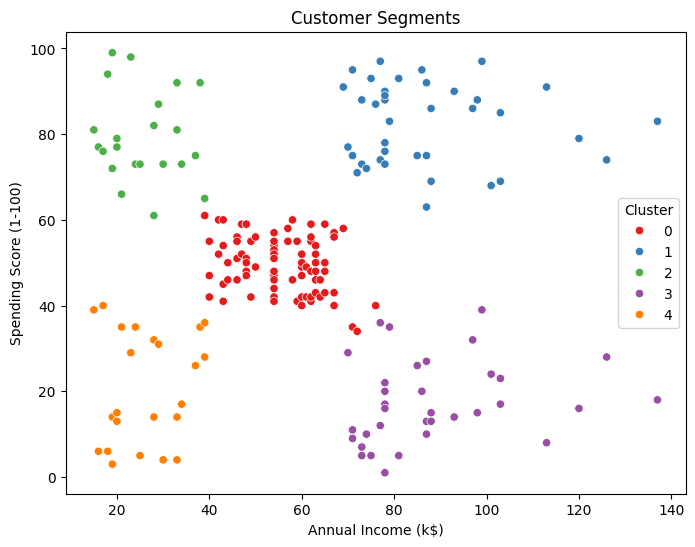

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=data,
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

### PCA Visualization (Required)

In [19]:
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

data['PCA1'] = x_pca[:,0]
data['PCA2'] = x_pca[:,1]
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance Kept:", sum(pca.explained_variance_ratio_).round(2))

Explained Variance: [0.50495142 0.49504858]
Total Variance Kept: 1.0


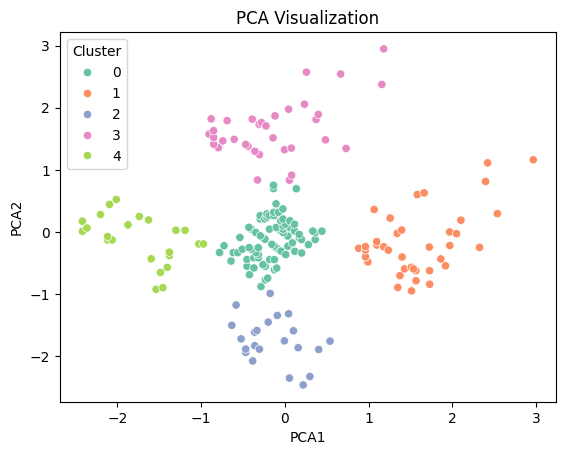

In [21]:
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=data,
    palette='Set2'
)

plt.title("PCA Visualization")
plt.show()

### Cluster Analysis

In [23]:
data.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),PCA1,PCA2
Cluster,,,,,,
0,86.320988,42.716049,55.296296,49.518519,-0.160774,-0.123359
1,162.000000,32.692308,86.538462,82.128205,1.577616,-0.175306
2,23.090909,25.272727,25.727273,79.363636,-0.139560,-1.740701
3,164.371429,41.114286,88.200000,17.114286,-0.162236,1.654235
4,23.000000,45.217391,26.304348,20.913043,-1.728511,-0.120599


###### These are average values per cluster

## Marketing Strategies

##### High Income + High Spending → Premium offers, loyalty programs

##### High Income + Low Spending → Encourage spending via exclusive deals

##### Low Income + High Spending → Offer affordable luxury products

##### Low Income + Low Spending → Discounts and promotions

##### Medium Customers → General marketing campaigns

## Conclusion

##### K-Means clustering successfully segmented customers into distinct groups based on income and spending behavior. PCA visualization helped clearly separate clusters. These insights can be used to design targeted marketing strategies and improve customer engagement.